# 1st Hidden Layer — Evaluate Little-Perturbation Checkpoints

In the 1st-layer perturbation sweeps, models trained with a *little*
perturbation tend to score better at their matched evaluation level. This
notebook isolates that effect: for each perturbation type it loads checkpoints
**trained at several small perturbation levels** and evaluates each one across
the **entire** perturbation sweep (eval-on-checkpoint), rather than training a
fresh model per level.

Each perturbation is evaluated twice — once for the **no-delay** model and once
for the **delay** model. Every plot overlays the checkpoints trained at several
levels together with the no-perturbation reference:

- **Relocation** — per-spike random relocation; checkpoints `f = 0.1, 0.2, 0.4`.
- **Jitter** — per-spike Gaussian jitter; checkpoints `sigma = 3, 5, 10`.
- **Shift** — per-neuron Gaussian shift; checkpoints `sigma = 3, 5, 10`.
- **Deletion** — per-spike deletion; checkpoints `p_d = 0.1, 0.2, 0.4`.

Evaluations cover the **whole / part / norm** SHD variants. The final sections
plot the eval-on-checkpoint sweeps (read from `log_eval_on_perturbatedModel/`)
against the **no-perturbation** model (a checkpoint trained on the clean dataset
and evaluated across the whole sweep), read from each perturbation's
`1stLayer_log/` folder and, for relocation, from `shd/1stLayer_log/`.

In [41]:
# Setup: reuse the 2nd-layer training modules (model classes, data pipeline
# and evaluation routines) so the evaluation matches the original sweeps.
import sys
import json
from pathlib import Path

import numpy as np
import torch

BASE_DIR = Path.cwd()
assert (BASE_DIR / "jitter").is_dir(), (
    "Run this notebook from my_project/code/perturbation/ so the "
    "jitter / shift / deletion packages are importable."
)

for sub in ("jitter", "shift", "deletion"):
    sub_path = str((BASE_DIR / sub).resolve())
    if sub_path not in sys.path:
        sys.path.append(sub_path)

# Dataset variants to evaluate (matches result_visualization_2ndLayer.ipynb).
EVAL_DATASETS = ("whole", "part", "norm")

# Destination for the eval-on-checkpoint sweep results.
EVAL_LOG_DIR = Path("log_eval_on_perturbatedModel")
EVAL_LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Eval results dir: {EVAL_LOG_DIR.resolve()}")

Eval results dir: D:\IC_2025\IRP\workspace\my_project\exp_fixed_weight_perturbation\result_visualization\PAT_results\perturbation\log_eval_on_perturbatedModel


## 4. Comparison: checkpoints trained at several perturbation levels

The four perturbation types are paired into two figures — relocation over
jitter, then shift over deletion — each a 2 x 3 grid whose rows are the two
perturbations and whose columns are the Whole / Part / Norm datasets. Both
delay modes share every panel, and each contributes three curves drawn in the
same style — dashed with **&#10005;** for no-delay, solid with **&#9679;** for
with-delay:

- **The two deeper shades** — a checkpoint trained at a given perturbation
  level, then evaluated across the whole sweep (read from
  `log_eval_on_perturbatedModel/`). Only the two higher training levels are
  plotted; the lowest-level checkpoint's slot goes to the clean model below.
- **The lightest shade** — the **no-perturbation** model: a single checkpoint
  trained on the clean dataset and evaluated across the whole sweep. For jitter
  and shift this is the
  `{pert}/1stLayer_log/{pert}_{ds}_{delay}_{pert}_sweep_results.json` file (the
  first-layer `*_train.py` scripts train one clean model, then sweep the
  perturbation at evaluation time); for deletion it is the
  `deletion/1stLayer_log/deletion_{ds}_{delay}_evalOnly_deletion_sweep_results.json`
  file; for relocation it is the
  `shd/1stLayer_log/shd_{ds}_{delay}_hidden_perturbation_results.json` file.

Three encodings are in play: **hue** = dataset (Whole / Part / Norm), fixed
within a panel; **colour depth** = the training level, the no-perturbation
model being the lightest shade and each higher training level a progressively
deeper shade of that hue; and **line style with marker** = delay mode (dashed
&#10005; no-delay, solid &#9679; with-delay). Relocation overlays checkpoints
trained at `f = 0.2, 0.4`; jitter and shift overlay `sigma = 5, 10`; deletion
overlays `p_d = 0.2, 0.4`. The rows measure different things along x, so the
y-axis is shared across a whole figure but the x-axis only within a row. The
level legend — a neutral grey ramp, since the hue differs per panel — is drawn
once per row, in the upper right of that row's Norm panel, because the levels
differ per perturbation; the delay-mode legend sits once beside it, in the
upper left of the top row's Norm panel. Section 5's
heatmaps still cover every trained level, the dropped one included.

Note that the relocation no-perturbation model is swept on a finer grid (`f` in
steps of 0.1) than its checkpoints (steps of 0.2), so its curves in that figure
are sampled more finely than the checkpoint ones.

In [42]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}
DS_LABEL = {"whole": "Whole", "part": "Part", "norm": "Norm"}


def shade(base_color, frac):
    """Return a lighter/darker variant of ``base_color`` keeping its hue.

    ``frac`` in ``[0, 1]`` maps the lightest variant (0, blended toward white)
    to the darkest variant (1, blended toward black), so higher perturbation
    levels can be drawn in a deeper shade of the same colour.
    """
    rgb = np.array(mcolors.to_rgb(base_color))
    lightest = rgb + (1.0 - rgb) * 0.55
    darkest = rgb * 0.45
    return tuple(lightest + (darkest - lightest) * frac)


def _depth_fracs(num_levels):
    """Depth positions for ``num_levels`` + 1 curves (light -> dark).

    Index 0 is the no-perturbation model (lightest); the ``num_levels``
    checkpoint curves then deepen as the training level increases.
    """
    total = num_levels + 1
    return [j / (total - 1) for j in range(total)]


def load_sweep(path, key_type=int):
    """Load a sweep JSON -> (levels, means_pct, stds_pct)."""
    with open(path) as fh:
        raw = json.load(fh)
    levels = sorted(key_type(k) for k in raw)
    means = np.array([raw[str(lvl)]["mean"] for lvl in levels]) * 100
    stds = np.array([raw[str(lvl)]["std"] for lvl in levels]) * 100
    return levels, means, stds


# Delay mode is encoded on every curve by both line style and marker: dashed
# with 'x' for no-delay, solid with a filled circle for with-delay.
DELAY_STYLES = {
    "nodelay": {"label": "No Delay", "linestyle": "--", "marker": "x",
                "markersize": 6},
    "delay": {"label": "With Delay", "linestyle": "-", "marker": "o",
              "markersize": 4},
}


def resolve_curve_series(cfg, dataset):
    """Return the curves to draw for one dataset, lightest shade first.

    The no-perturbation model takes the slot of the lowest-level checkpoint,
    which is dropped, so each delay mode contributes three curves drawn in the
    same style: the clean model — labelled as level zero — plus the two higher
    training levels.

    Args:
        cfg: Panel config from one of the ``_*_config`` builders.
        dataset: Dataset variant key ('whole' / 'part' / 'norm').

    Returns:
        A list of ``(label, path)`` pairs in ascending training-level order.
    """
    curves = [(f"{cfg['symbol']}=0", cfg["baseline_paths"][dataset])]
    curves += [(label, paths[dataset])
               for label, paths in cfg["level_series"][1:]]
    return curves


def build_level_handles(labels):
    """Legend handles for the training-level depth ramp, in neutral grey.

    Each panel draws its curves in one dataset hue, so the shared legend uses a
    grey ramp to convey only the light -> dark ordering of the training levels.
    Line style and marker are left off here because they encode the delay mode
    instead.
    """
    fracs = _depth_fracs(len(labels) - 1)
    grey = "#7f7f7f"
    return [
        mlines.Line2D([], [], color=shade(grey, frac), linestyle="-",
                      linewidth=1.6, label=label)
        for frac, label in zip(fracs, labels)
    ]


def build_delay_handles(delay_tags):
    """Legend handles showing how each delay mode is drawn, in neutral black."""
    return [
        mlines.Line2D([], [], color="black",
                      linestyle=DELAY_STYLES[tag]["linestyle"],
                      marker=DELAY_STYLES[tag]["marker"],
                      markersize=DELAY_STYLES[tag]["markersize"],
                      linewidth=1.6, label=DELAY_STYLES[tag]["label"])
        for tag in delay_tags
    ]


def plot_dataset_panel(ax, dataset, configs_by_delay, xlabel, title, xlim,
                       show_ylabel=True):
    """Overlay both delay modes' eval-on-checkpoint sweeps for one dataset.

    Three encodings share the axis: the hue is fixed by ``dataset``, the depth
    of that hue is the training perturbation level (the no-perturbation model
    is the lightest shade), and the line style with its marker is the delay
    mode. The y-limit is left to the caller so that panels sharing a y-axis can
    be scaled once, after every panel has been drawn.

    Args:
        ax: Target axes.
        dataset: Dataset variant key ('whole' / 'part' / 'norm').
        configs_by_delay: Mapping from delay tag to that mode's panel config.
        xlabel: Label for the shared evaluation-level axis.
        title: Panel title.
        xlim: Evaluation-level axis limits.
        show_ylabel: Whether to label the y-axis (left-hand panel only).
    """
    base = COLORS[DS_LABEL[dataset]]

    for delay_tag, cfg in configs_by_delay.items():
        style = DELAY_STYLES[delay_tag]
        curves = resolve_curve_series(cfg, dataset)
        fracs = _depth_fracs(len(curves) - 1)
        for frac, (_, path) in zip(fracs, curves):
            x, means, _ = load_sweep(path, cfg["key_type"])
            ax.plot(x, means, linestyle=style["linestyle"],
                    marker=style["marker"], color=shade(base, frac),
                    markersize=style["markersize"], linewidth=1.6)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    if show_ylabel:
        ax.set_ylabel("Test Accuracy (%)")
    ax.set_xlim(*xlim)
    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)


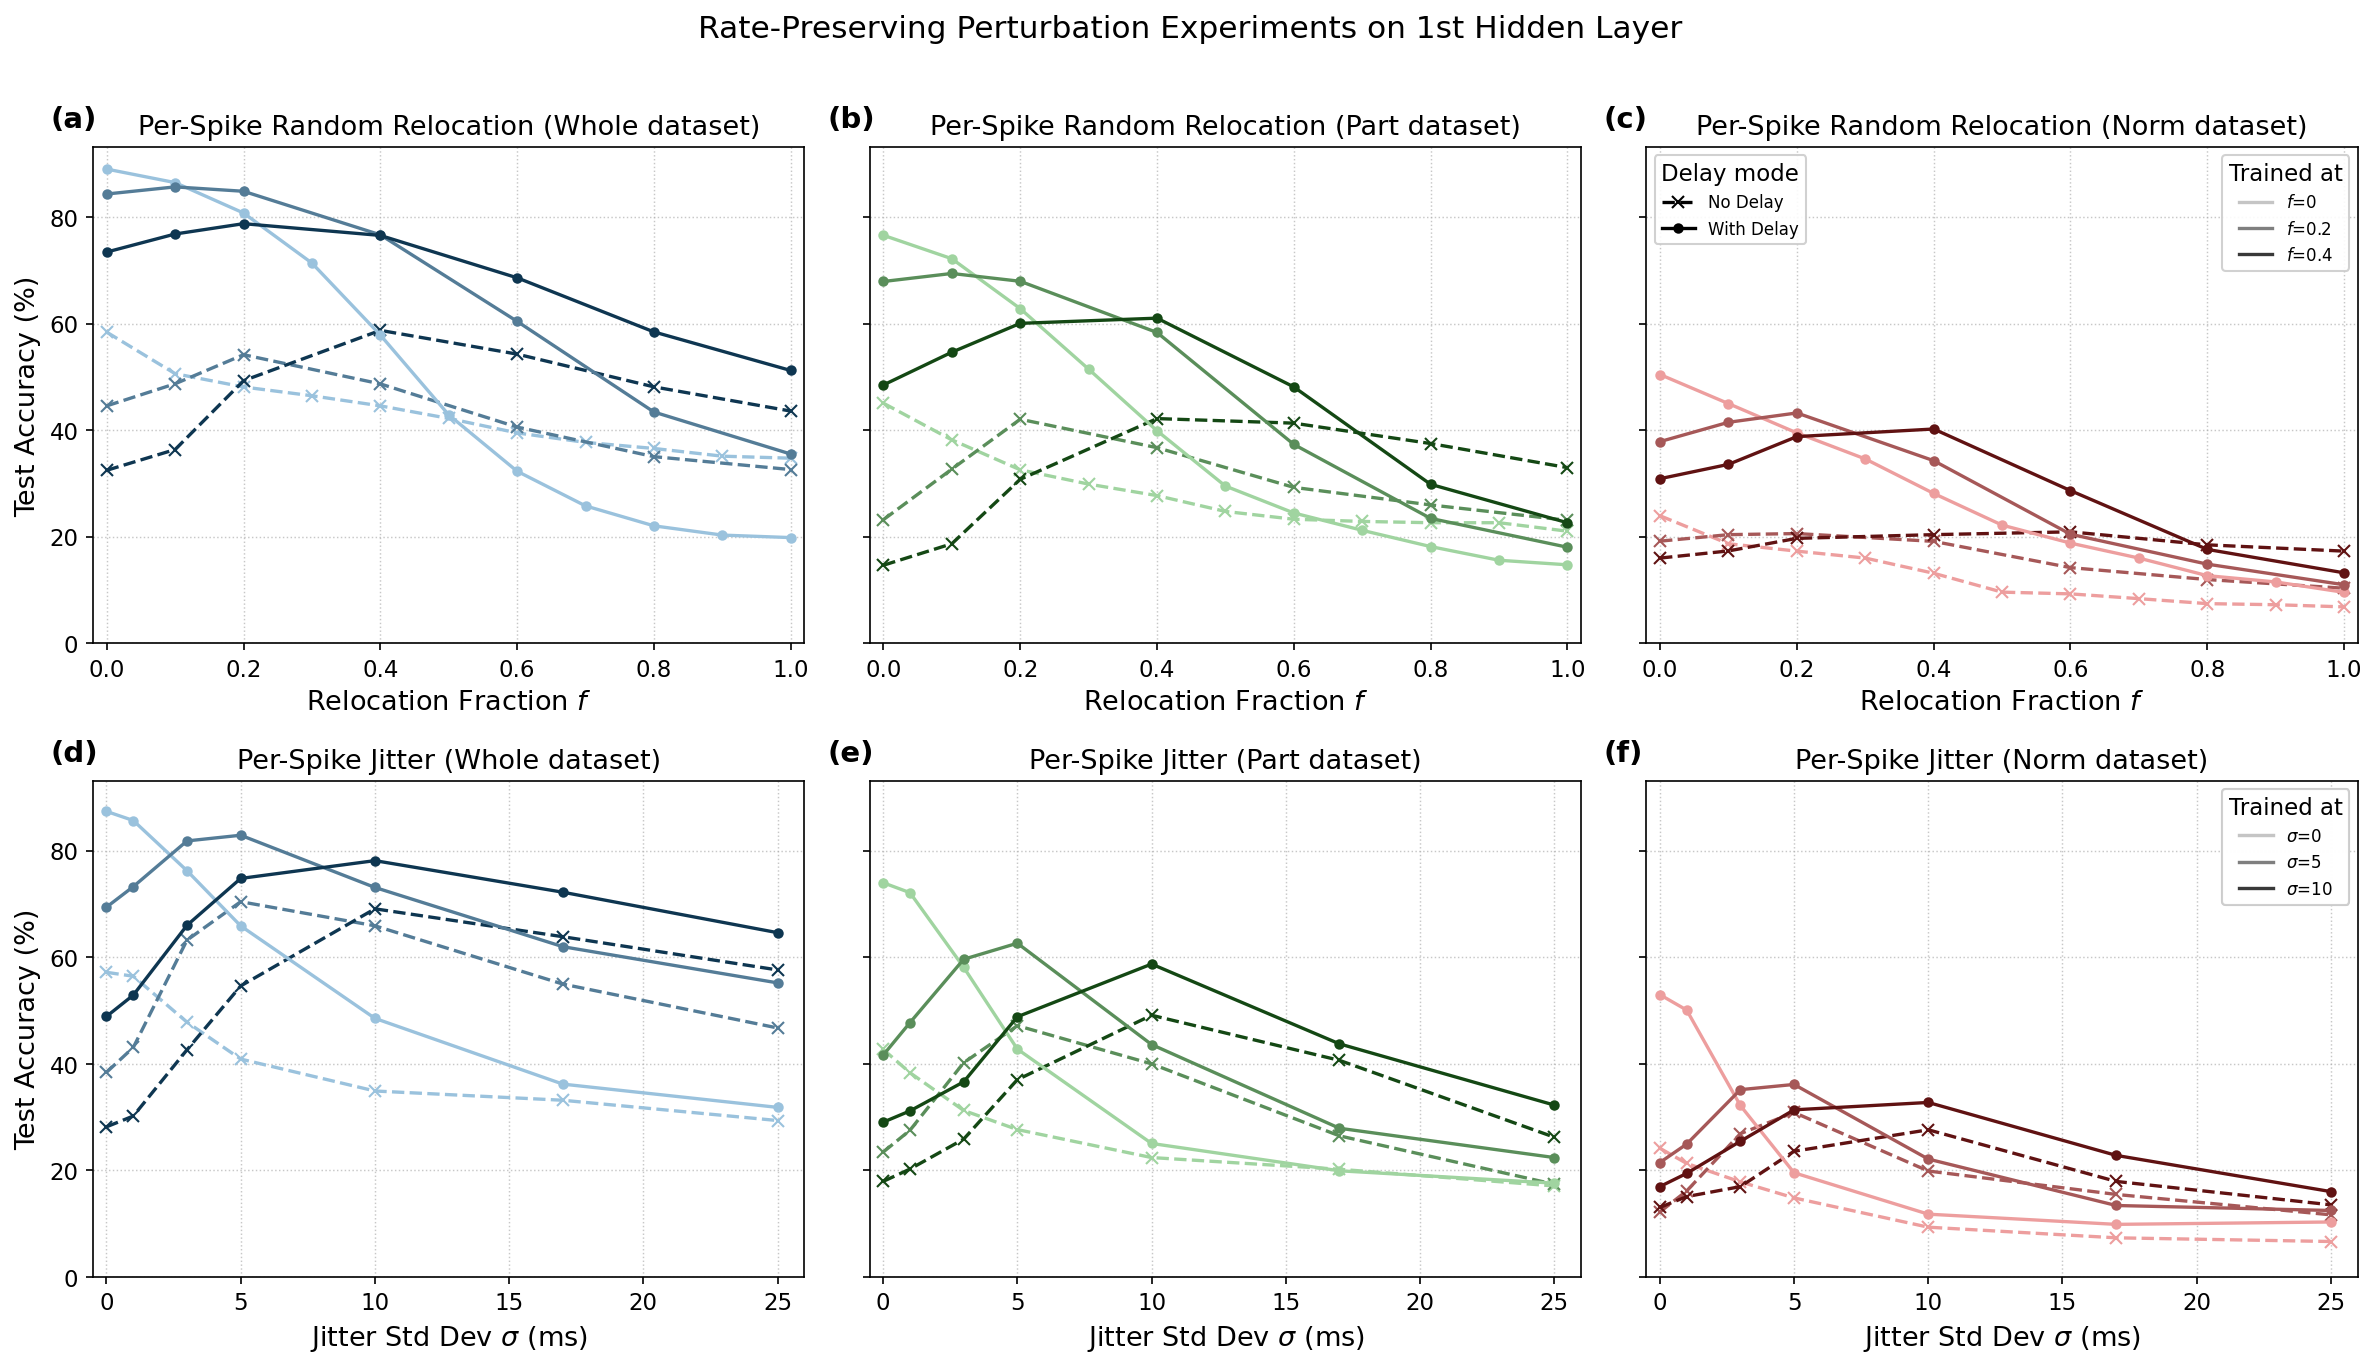

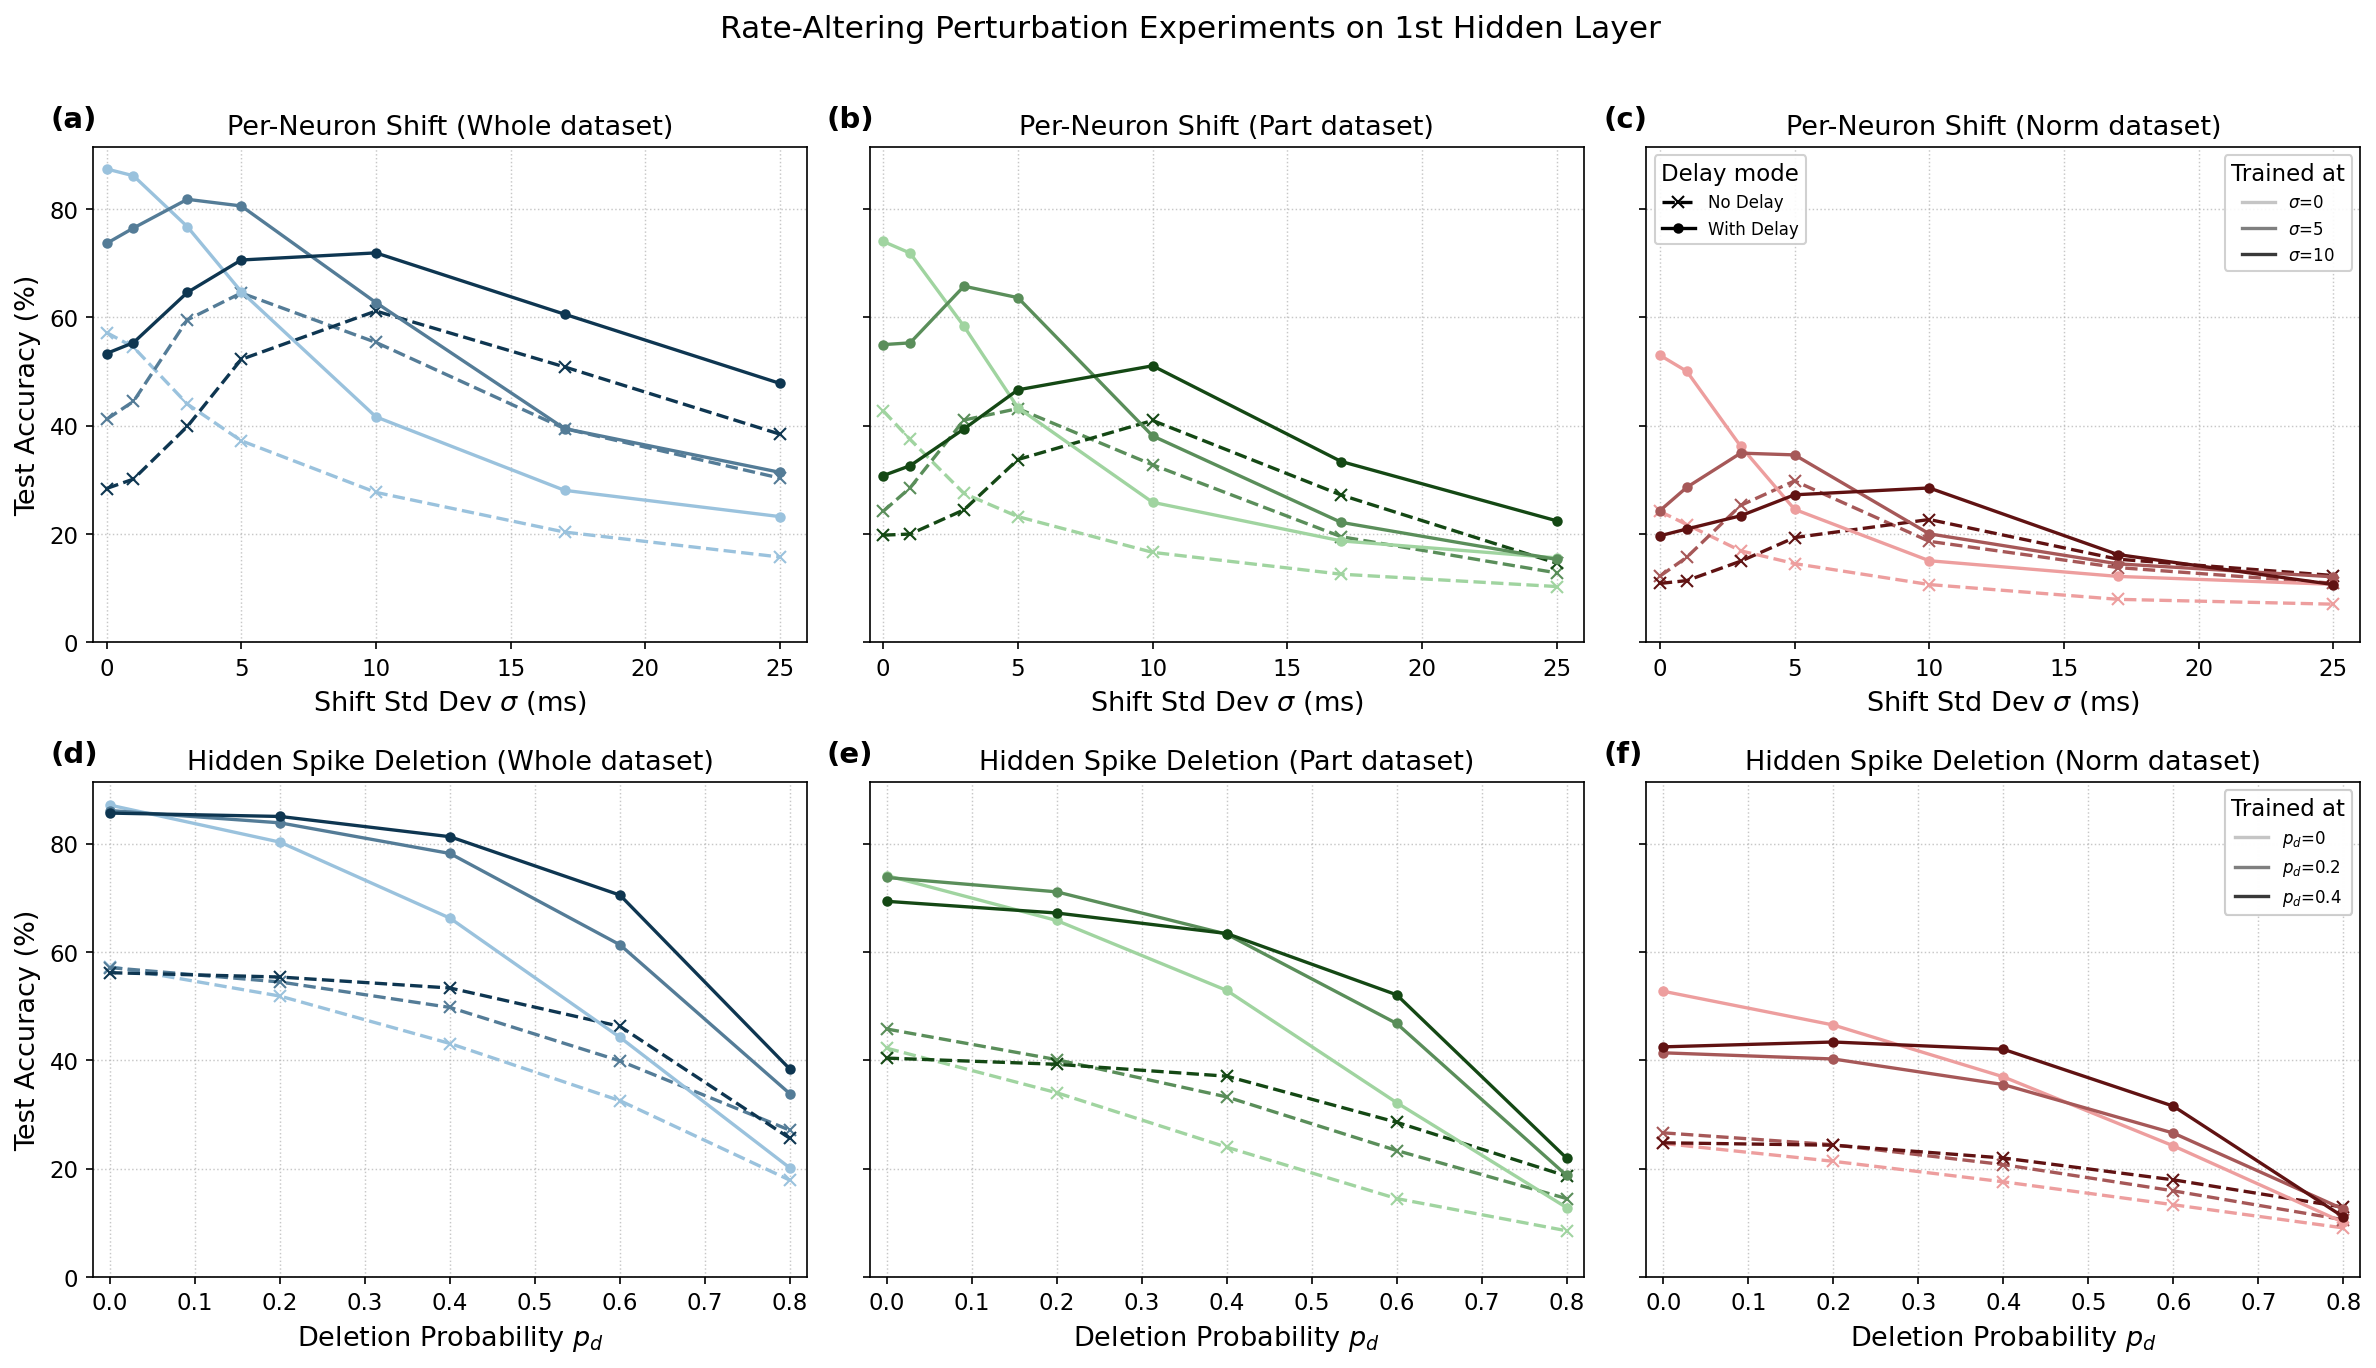

In [43]:
# Two comparison figures, each pairing two perturbation types as the rows of a
# 2 x 3 grid whose columns are the datasets (whole / part / norm), with both
# delay modes overlaid. Checkpoints trained at each perturbation level to
# overlay per panel.
RELOCATION_CKPT_FS = [0.1, 0.2, 0.4]
JITTER_CKPT_SIGMAS = [3, 5, 10]
SHIFT_CKPT_SIGMAS = [3, 5, 10]
DELETION_CKPT_PDS = [0.1, 0.2, 0.4]

DELAY_LABEL = {tag: style["label"]
               for tag, style in DELAY_STYLES.items()}


def _pd_token(p_d):
    """File token for a deletion probability, e.g. 0.2 -> 'pd02'."""
    return f"pd{int(round(p_d * 10)):02d}"


def _relocation_config(delay_tag):
    """Build the per-spike random relocation panel config for one delay mode.

    The relocation sweeps are the Phase 2 realistic SHD runs: the baseline is the
    clean checkpoint's hidden-perturbation sweep in ``shd/1stLayer_log/``.
    """
    level_series = [
        (rf"$f$={f}", {
            ds: EVAL_LOG_DIR / f"shd_1stLayer_{ds}_{delay_tag}_evalon_f{f}.json"
            for ds in EVAL_DATASETS
        })
        for f in RELOCATION_CKPT_FS
    ]
    baseline_paths = {
        ds: Path("shd/1stLayer_log")
        / f"shd_{ds}_{delay_tag}_hidden_perturbation_results.json"
        for ds in EVAL_DATASETS
    }
    return dict(
        level_series=level_series, baseline_paths=baseline_paths, key_type=float,
        xlabel=r"Relocation Fraction $f$", xlim=(-0.02, 1.02),
        symbol=r"$f$", name="Per-Spike Random Relocation",
    )


def _jitter_config(delay_tag):
    """Build the jitter panel config for one delay mode."""
    level_series = [
        (rf"$\sigma$={sigma}", {
            ds: EVAL_LOG_DIR
            / f"jitter_1stLayer_{ds}_{delay_tag}_evalon_sigma{sigma}.json"
            for ds in EVAL_DATASETS
        })
        for sigma in JITTER_CKPT_SIGMAS
    ]
    baseline_paths = {
        ds: Path("jitter/1stLayer_log")
        / f"jitter_{ds}_{delay_tag}_jitter_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    return dict(
        level_series=level_series, baseline_paths=baseline_paths, key_type=int,
        xlabel=r"Jitter Std Dev $\sigma$ (ms)", xlim=(-0.5, 26),
        symbol=r"$\sigma$", name="Per-Spike Jitter",
    )


def _shift_config(delay_tag):
    """Build the shift panel config for one delay mode."""
    level_series = [
        (rf"$\sigma$={sigma}", {
            ds: EVAL_LOG_DIR
            / f"shift_1stLayer_{ds}_{delay_tag}_evalon_sigma{sigma}.json"
            for ds in EVAL_DATASETS
        })
        for sigma in SHIFT_CKPT_SIGMAS
    ]
    baseline_paths = {
        ds: Path("shift/1stLayer_log")
        / f"shift_{ds}_{delay_tag}_shift_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    return dict(
        level_series=level_series, baseline_paths=baseline_paths, key_type=int,
        xlabel=r"Shift Std Dev $\sigma$ (ms)", xlim=(-0.5, 26),
        symbol=r"$\sigma$", name="Per-Neuron Shift",
    )


def _deletion_config(delay_tag):
    """Build the deletion panel config for one delay mode."""
    level_series = [
        (rf"$p_d$={p_d}", {
            ds: EVAL_LOG_DIR
            / f"deletion_1stLayer_{ds}_{delay_tag}_evalon_{_pd_token(p_d)}.json"
            for ds in EVAL_DATASETS
        })
        for p_d in DELETION_CKPT_PDS
    ]
    baseline_paths = {
        ds: Path("deletion/1stLayer_log")
        / f"deletion_{ds}_{delay_tag}_evalOnly_deletion_sweep_results.json"
        for ds in EVAL_DATASETS
    }
    return dict(
        level_series=level_series, baseline_paths=baseline_paths, key_type=float,
        xlabel=r"Deletion Probability $p_d$", xlim=(-0.02, 0.82),
        symbol=r"$p_d$", name="Hidden Spike Deletion",
    )


# Two perturbations per figure, as its rows; the columns are the dataset
# variants and both delay modes share each panel.
PERTURBATION_BUILDERS = (
    _relocation_config, _jitter_config, _shift_config, _deletion_config,
)
# Each pair is grouped by what it does to the spike count, which names the
# figure: relocation and jitter move spikes around, shift and deletion change
# how many arrive.
PERTURBATION_PAIRS = (
    ((_relocation_config, _jitter_config), "Rate-Preserving"),
    ((_shift_config, _deletion_config), "Rate-Altering"),
)
DELAY_TAGS = ("nodelay", "delay")
NUM_PERTURBATIONS = len(PERTURBATION_BUILDERS)


def draw_perturbation_pair_figure(row_builders, category) -> plt.Figure:
    """Draw two perturbations' eval-on-checkpoint sweeps in one 2x3 figure.

    The rows are the two perturbations and the columns the dataset variants
    (whole, part, norm); every panel overlays both delay modes. The rows have
    different evaluation-level units, so only the y-axis is shared across the
    whole figure and the x-axis within each row. Each row carries its own
    training-level legend, in its Norm panel; the delay-mode legend is drawn
    once, in the upper left of the top row's Norm panel.

    Args:
        row_builders: Two ``_*_config`` builders, top row then bottom row.
        category: What the pair does to the spike count ('Rate-Preserving' or
            'Rate-Altering'), which opens the figure's title.

    Returns:
        The completed figure.
    """
    fig, axes = plt.subplots(len(row_builders), len(EVAL_DATASETS),
                             figsize=(16, 9), sharex="row", sharey=True)

    for row, build_config in enumerate(row_builders):
        configs_by_delay = {tag: build_config(tag) for tag in DELAY_TAGS}
        reference = configs_by_delay[DELAY_TAGS[0]]

        for col, ds in enumerate(EVAL_DATASETS):
            ax = axes[row, col]
            plot_dataset_panel(
                ax, ds, configs_by_delay, xlabel=reference["xlabel"],
                title=f"{reference['name']} ({DS_LABEL[ds]} dataset)",
                xlim=reference["xlim"], show_ylabel=(col == 0),
            )
            panel_label = chr(ord("a") + row * len(EVAL_DATASETS) + col)
            ax.text(-0.06, 1.04, f"({panel_label})", transform=ax.transAxes,
                    fontsize=14, fontweight="bold")

        # The level labels differ per perturbation, so each row needs its own
        # legend; the Norm panel has the room for it. Registering it as an
        # artist keeps it when the same axes gains a second legend below.
        level_labels = [label for label, _
                        in resolve_curve_series(reference, EVAL_DATASETS[0])]
        level_legend = axes[row, -1].legend(
            handles=build_level_handles(level_labels), loc="upper right",
            framealpha=0.9, title="Trained at", fontsize=8)
        axes[row, -1].add_artist(level_legend)

    axes[0, -1].legend(handles=build_delay_handles(DELAY_TAGS), loc="upper left",
                       framealpha=0.9, title="Delay mode", fontsize=8)

    # Anchor the shared y-axis at 0 only once everything is drawn, so the
    # autoscaled top still covers the highest curve in the figure.
    axes[0, 0].set_ylim(bottom=0)

    fig.suptitle(
        f"{category} Perturbation Experiments on 1st Hidden Layer",
        y=1.01, fontsize=15)
    fig.tight_layout()
    return fig


for pair_builders, pair_category in PERTURBATION_PAIRS:
    draw_perturbation_pair_figure(pair_builders, pair_category)
    plt.show()


## 5. Eval-on-Checkpoint Heatmaps

The same eval-on-checkpoint sweeps from Section 4 are shown again as
heatmaps, one figure per dataset variant (Whole / Part / Norm). Within each
figure the panels are arranged as **2 rows** (no-delay / with-delay)
&times; **4 columns** (relocation / jitter / shift / deletion) — all four
perturbations of Section 4 in one grid — and each panel is a grid of cells
instead of a line plot:

- **Rows** — the perturbation level the checkpoint was **trained** at
  (`no perturbation` baseline, then each checkpoint level in ascending order).
- **Columns** — the perturbation level the model is **evaluated** at, i.e.
  the full sweep.
- **Cell colour / annotation** — test accuracy (%) at that
  (train level, eval level) pair. Darker cells mean higher accuracy; every
  cell is also annotated with its value. All panels in this section (and
  across all three dataset figures) share the same colour scale (0-100%), so
  colour is directly comparable across panels.

A heatmap needs one shared column axis, so each panel is restricted to the eval
levels every row has in common. This is a no-op for jitter, shift and deletion,
whose baseline and checkpoint sweeps use identical grids; for relocation it drops
the baseline-only odd multiples of 0.1, keeping `f = 0.0, 0.2, ..., 1.0`.

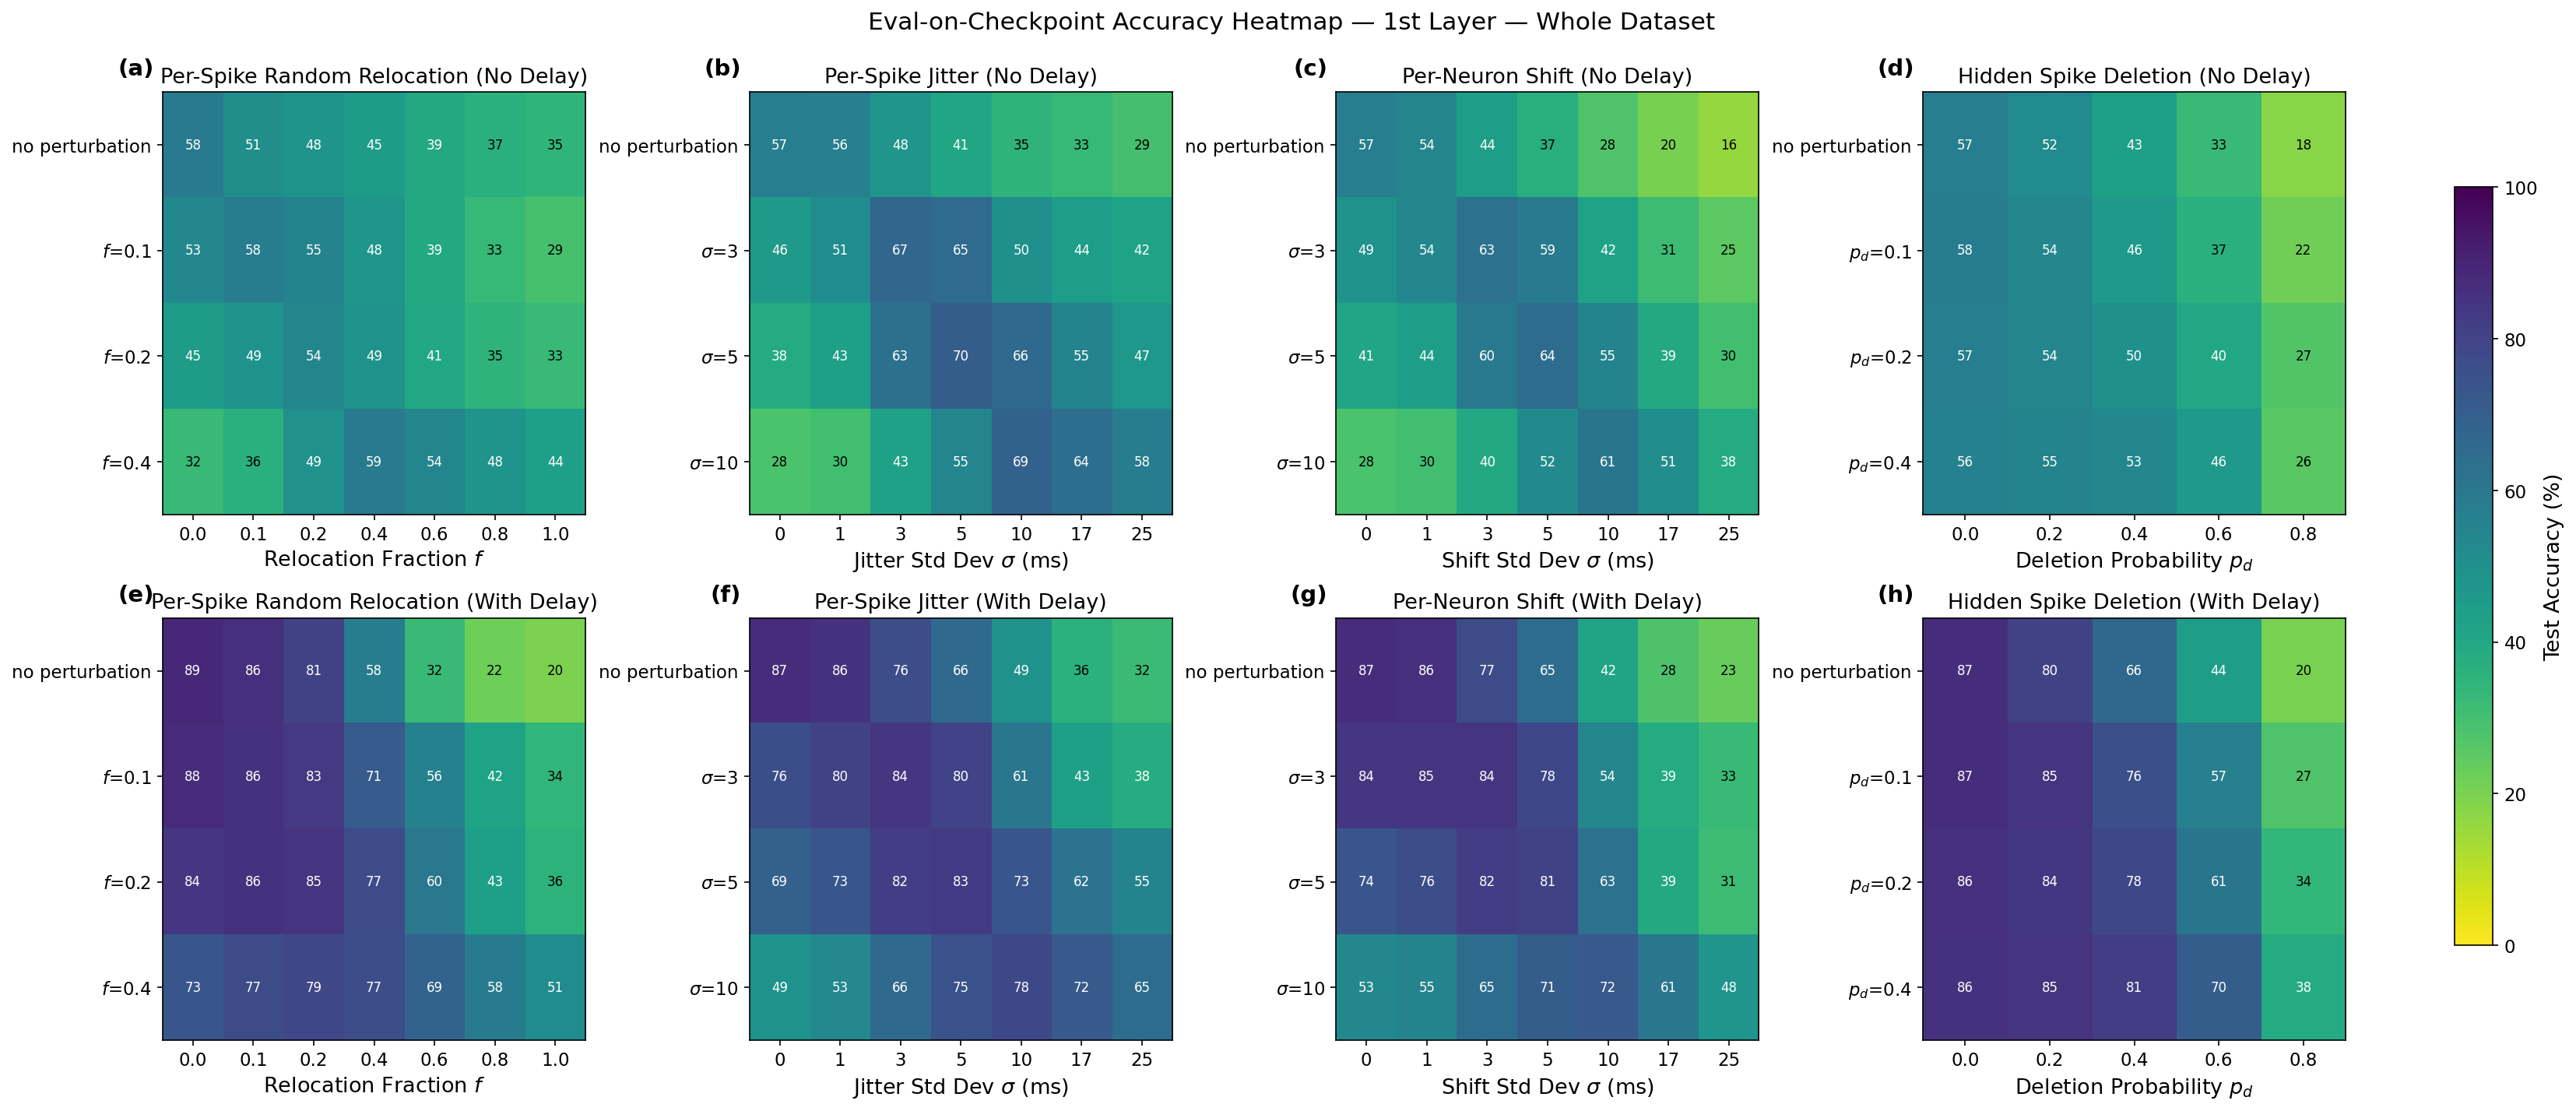

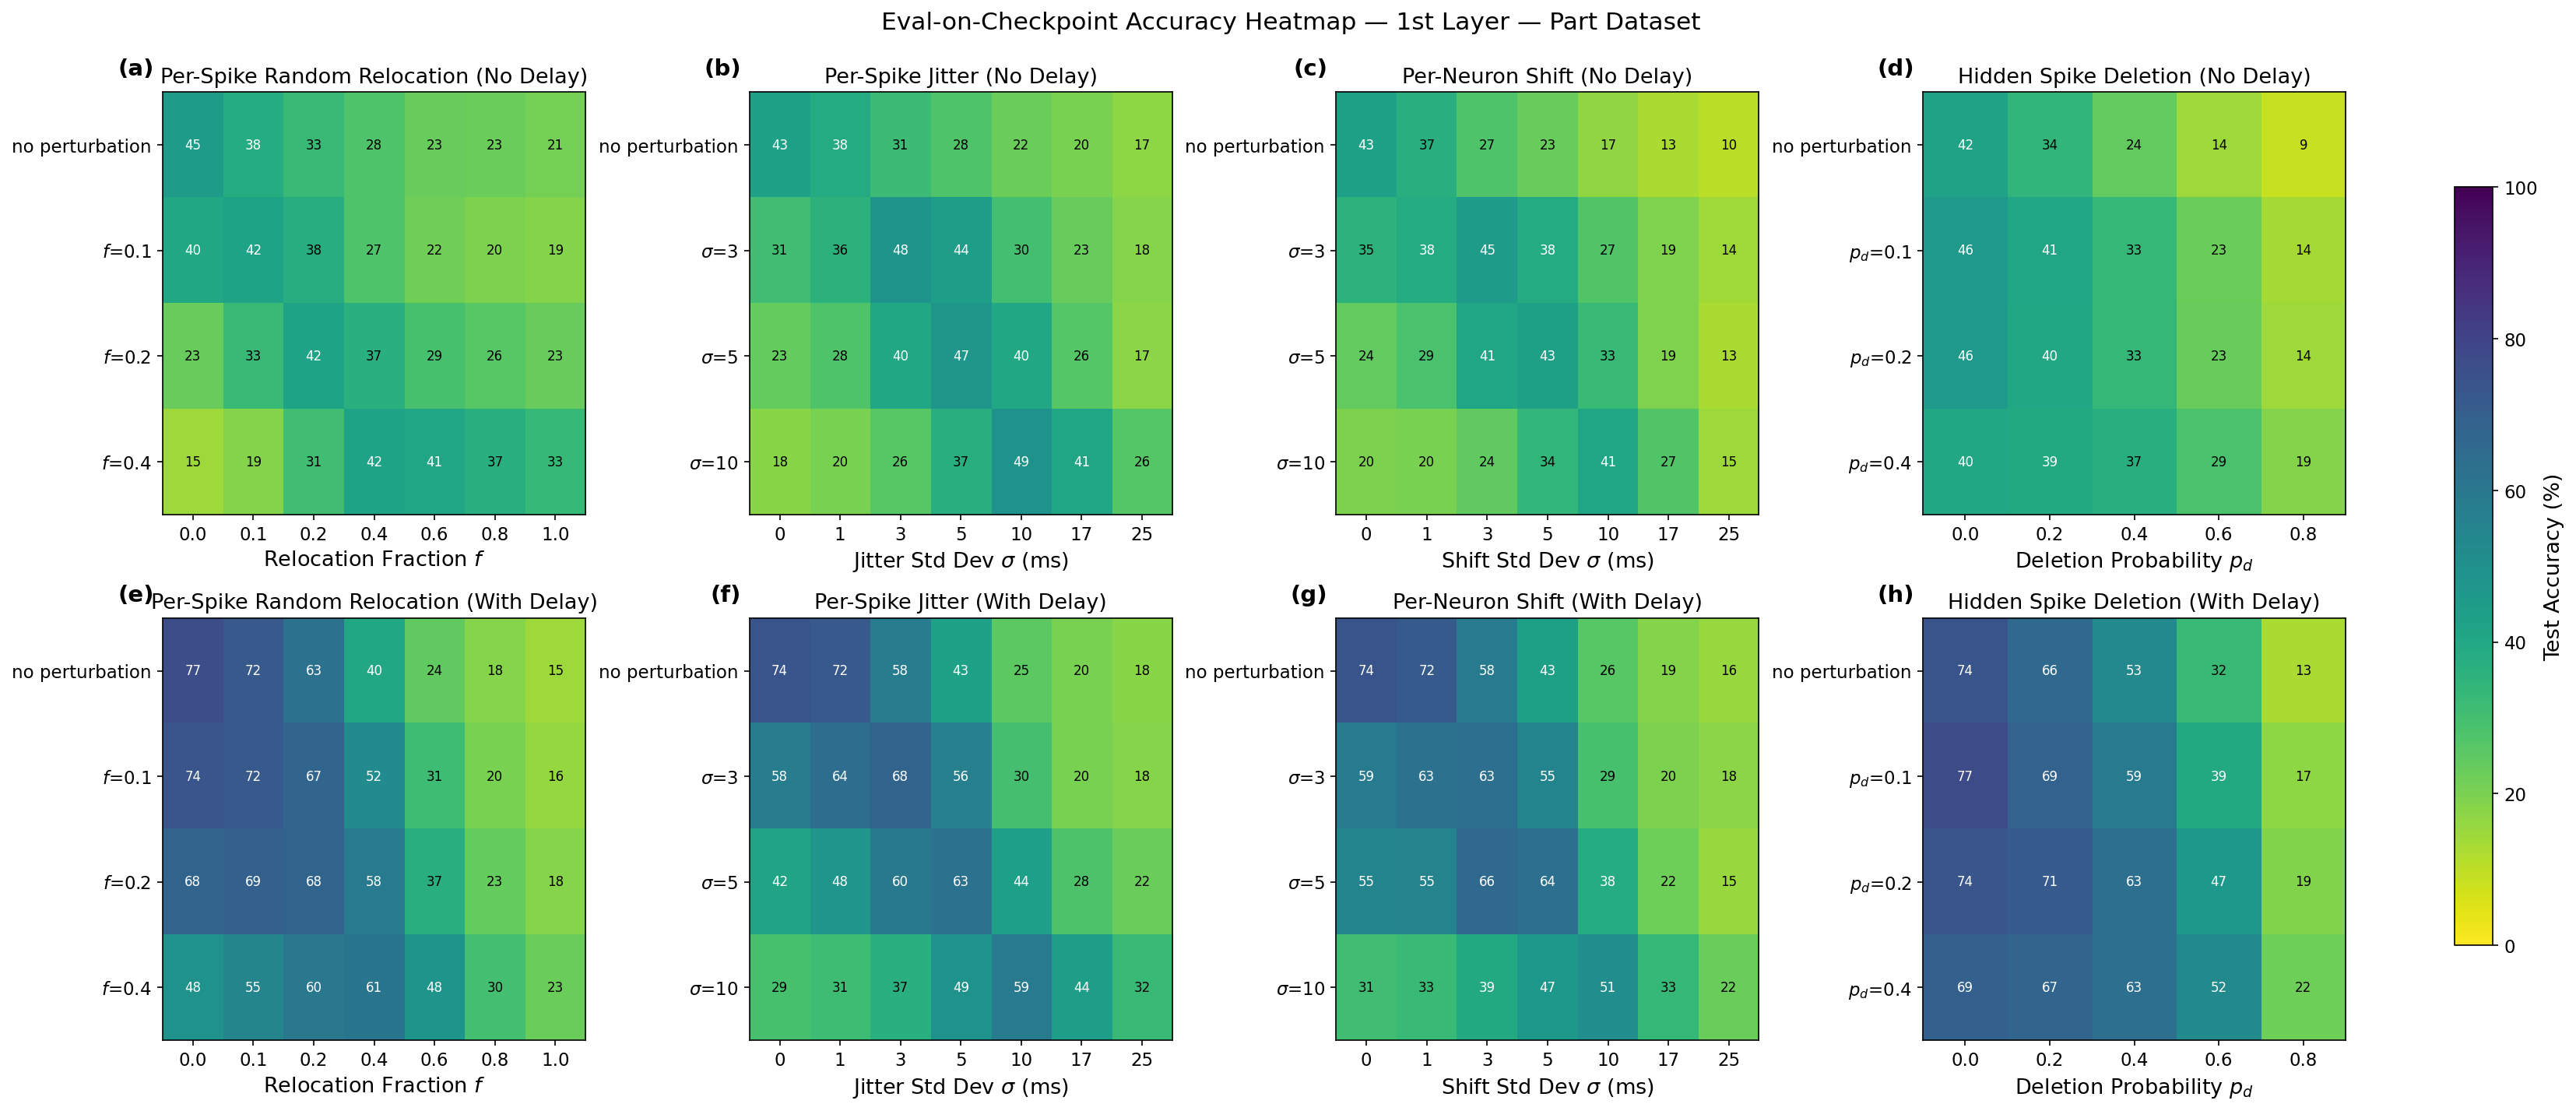

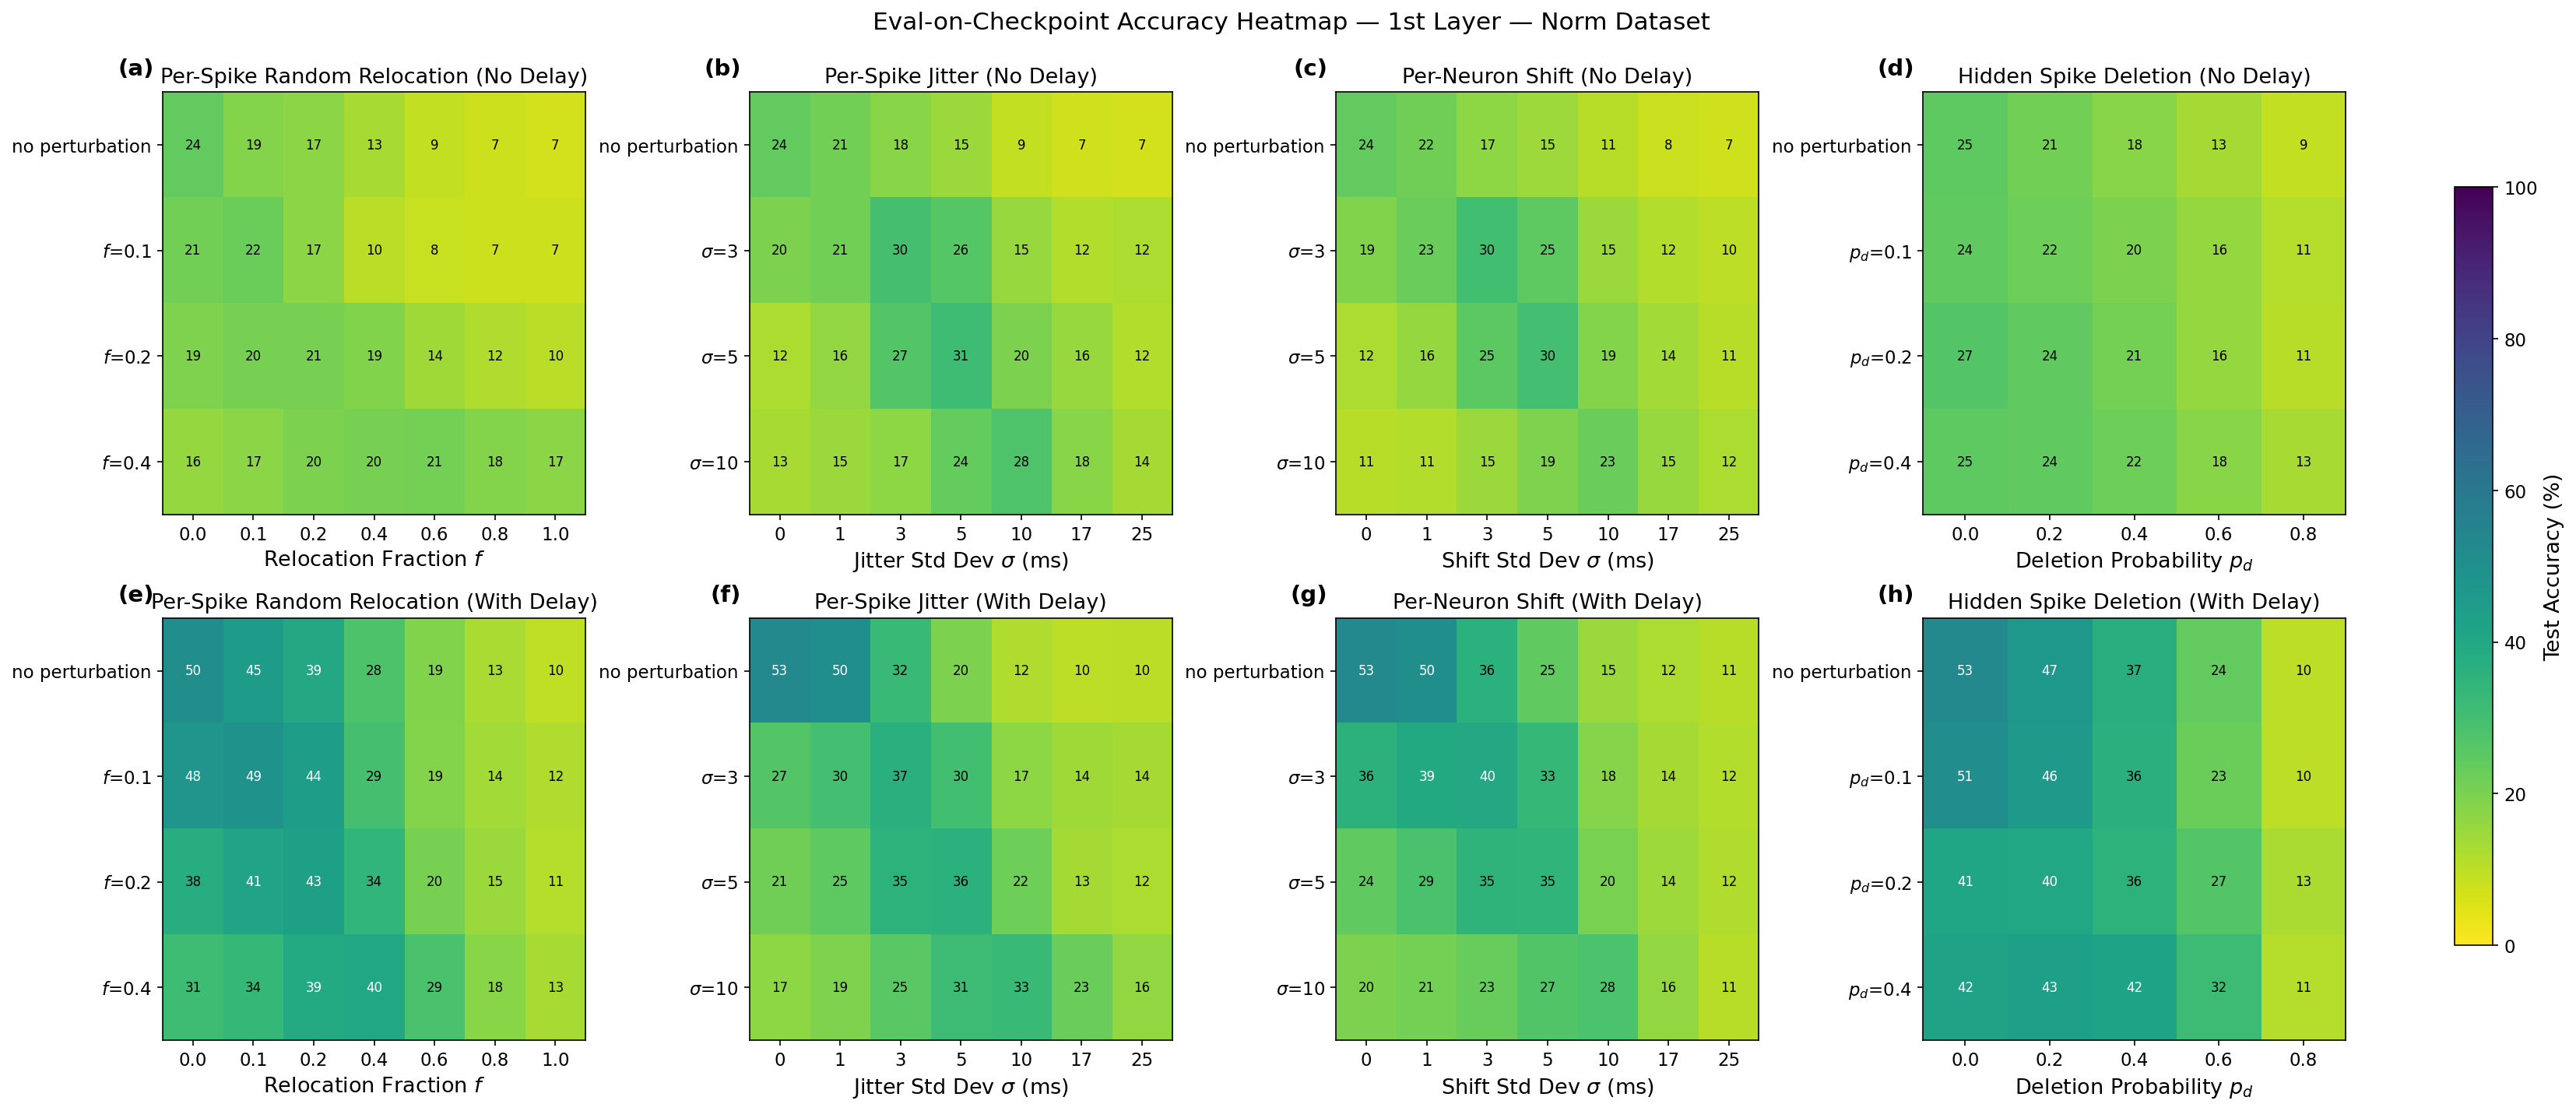

In [44]:
def build_heatmap_matrix(ds, delay_tag, build_config):
    """Build a (train_level x eval_level) accuracy-% matrix for one panel.

    Row 0 is the no-perturbation baseline; the remaining rows are the
    checkpoints trained at each perturbation level, in ascending order.
    Columns follow the evaluation sweep, in ascending order, restricted to the
    levels every row shares — the relocation baseline is swept on a finer grid
    than its checkpoints, so without this the rows would not be alignable.
    """
    cfg = build_config(delay_tag)
    baseline_levels, baseline_means, _ = load_sweep(cfg["baseline_paths"][ds], cfg["key_type"])
    rows = [("no perturbation", baseline_levels, baseline_means)]
    for label, paths in cfg["level_series"]:
        levels, means, _ = load_sweep(paths[ds], cfg["key_type"])
        rows.append((label, levels, means))

    shared = set.intersection(*(set(levels) for _, levels, _ in rows))
    eval_levels = [lvl for lvl in rows[0][1] if lvl in shared]
    train_labels = [label for label, _, _ in rows]
    matrix = np.array([
        [means[levels.index(lvl)] for lvl in eval_levels]
        for _, levels, means in rows
    ])
    return eval_levels, train_labels, matrix


def _heatmap_text_color(value, cmap, norm):
    """Pick black/white text for readable contrast against the cell colour."""
    r, g, b, _ = cmap(norm(value))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "black" if luminance > 0.5 else "white"


def draw_heatmap_panel(ax, eval_levels, train_labels, matrix, title, xlabel, cmap, norm):
    """Draw one train-level x eval-level accuracy heatmap onto ``ax``."""
    im = ax.imshow(matrix, aspect="auto", cmap=cmap, norm=norm)
    ax.set_xticks(range(len(eval_levels)))
    ax.set_xticklabels([str(v) for v in eval_levels])
    ax.set_yticks(range(len(train_labels)))
    ax.set_yticklabels(train_labels)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i, j]:.0f}", ha="center", va="center",
                    fontsize=8, color=_heatmap_text_color(matrix[i, j], cmap, norm))
    return im


HEATMAP_CMAP = plt.get_cmap("viridis_r")
HEATMAP_NORM = mcolors.Normalize(vmin=0, vmax=100)

for ds in EVAL_DATASETS:
    fig, axes = plt.subplots(2, NUM_PERTURBATIONS, figsize=(22, 9), constrained_layout=True)
    im = None
    for row, delay_tag in enumerate(DELAY_TAGS):
        for col, build_config in enumerate(PERTURBATION_BUILDERS):
            cfg = build_config(delay_tag)
            eval_levels, train_labels, matrix = build_heatmap_matrix(ds, delay_tag, build_config)
            ax = axes[row, col]
            im = draw_heatmap_panel(
                ax, eval_levels, train_labels, matrix,
                title=f"{cfg['name']} ({DELAY_LABEL[delay_tag]})",
                xlabel=cfg["xlabel"], cmap=HEATMAP_CMAP, norm=HEATMAP_NORM,
            )
            # Right-aligned at the axes' left edge: with four columns the titles
            # are wide enough to reach a left-aligned label and overlap it.
            panel_label = chr(ord("a") + row * NUM_PERTURBATIONS + col)
            ax.text(-0.02, 1.04, f"({panel_label})", transform=ax.transAxes,
                    ha="right", fontsize=14, fontweight="bold")

    fig.suptitle(
        f"Eval-on-Checkpoint Accuracy Heatmap — 1st Layer — {DS_LABEL[ds]} Dataset",
        y=1.04, fontsize=15,
    )
    fig.colorbar(im, ax=axes, shrink=0.8, label="Test Accuracy (%)")
    plt.show()